In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

print('Library berhasil diimport!')

Library berhasil diimport!


In [2]:
df = pd.read_csv('../Dataset/spam.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']
print('Shape dataset:', df.shape)
df.head()

Shape dataset: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


Distribusi Label:
label
ham     4825
spam     747
Name: count, dtype: int64


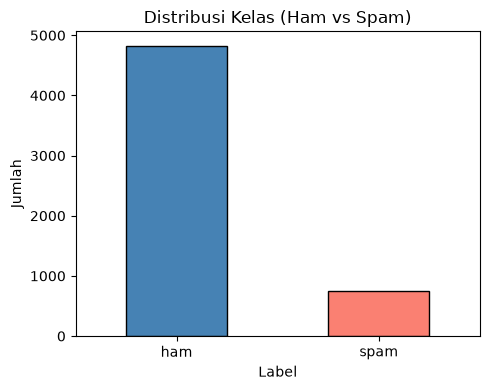

In [4]:
print('Distribusi Label:')
print(df['label'].value_counts())

plt.figure(figsize=(5, 4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Distribusi Kelas (Ham vs Spam)')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
label    0
text     0
dtype: int64


In [6]:
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Ukuran data train:', X_train.shape)
print('Ukuran data test :', X_test.shape)

Ukuran data train: (4457,)
Ukuran data test : (1115,)


In [7]:
cv = CountVectorizer(stop_words='english')
X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

print('Jumlah fitur CountVectorizer:', X_train_cv.shape[1])

Jumlah fitur CountVectorizer: 7440


In [8]:
mnb_cv = MultinomialNB()
mnb_cv.fit(X_train_cv, y_train)
y_pred_cv = mnb_cv.predict(X_test_cv)

acc_cv = accuracy_score(y_test, y_pred_cv)
print('Akurasi Model CountVectorizer: {:.4f}'.format(acc_cv))

Akurasi Model CountVectorizer: 0.9839


In [9]:
print('Classification Report (CountVectorizer):')
print(classification_report(y_test, y_pred_cv, target_names=['ham', 'spam']))

Classification Report (CountVectorizer):
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



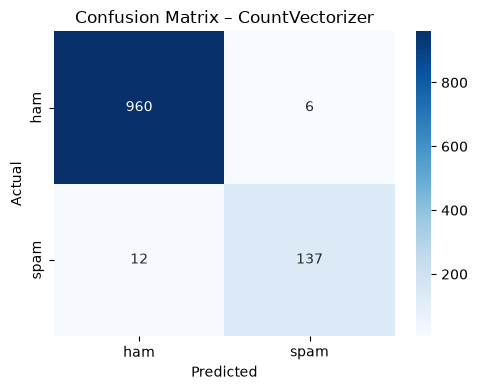

In [10]:
cm_cv = confusion_matrix(y_test, y_pred_cv)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix – CountVectorizer')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [11]:
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('Jumlah fitur TF-IDF:', X_train_tfidf.shape[1])

Jumlah fitur TF-IDF: 7440


In [12]:
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print('Akurasi Model TF-IDF: {:.4f}'.format(acc_tfidf))

Akurasi Model TF-IDF: 0.9686


In [13]:
print('Classification Report (TF-IDF):')
print(classification_report(y_test, y_pred_tfidf, target_names=['ham', 'spam']))

Classification Report (TF-IDF):
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



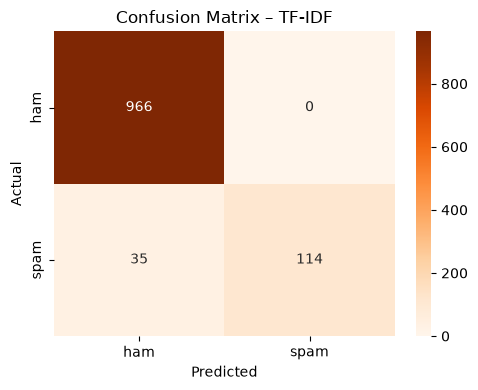

In [14]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix – TF-IDF')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

          Model  Akurasi
CountVectorizer 0.983857
         TF-IDF 0.968610


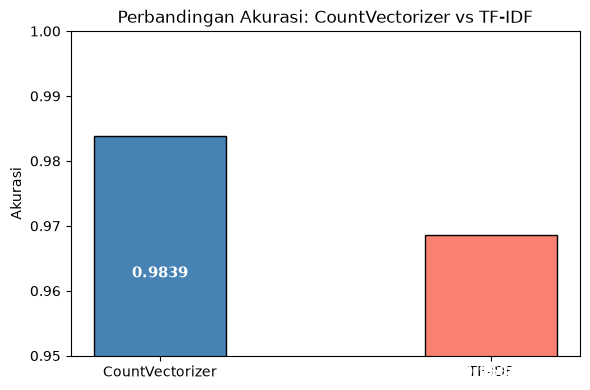

In [15]:
results = pd.DataFrame({
    'Model': ['CountVectorizer', 'TF-IDF'],
    'Akurasi': [acc_cv, acc_tfidf]
})

print(results.to_string(index=False))

plt.figure(figsize=(6, 4))
bars = plt.bar(results['Model'], results['Akurasi'],
               color=['steelblue', 'salmon'], edgecolor='black', width=0.4)
for bar, val in zip(bars, results['Akurasi']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
             f'{val:.4f}', ha='center', va='top', fontsize=11, color='white', fontweight='bold')
plt.ylim(0.95, 1.0)
plt.title('Perbandingan Akurasi: CountVectorizer vs TF-IDF')
plt.ylabel('Akurasi')
plt.tight_layout()
plt.show()

Berdasarkan eksperimen klasifikasi spam menggunakan Multinomial Naive Bayes pada dataset spam.csv dengan dua pendekatan ekstraksi fitur, diperoleh hasil sebagai berikut:

CountVectorizer merepresentasikan teks berdasarkan frekuensi kemunculan kata mentah (raw count). Pendekatan ini efektif karena kata-kata yang sering muncul di pesan spam — seperti 'free', 'win', 'prize' — secara langsung memperkuat bobot fitur tersebut dalam model.

TF-IDF (Term Frequency-Inverse Document Frequency) memberikan bobot yang lebih rendah pada kata yang umum muncul di seluruh dokumen, dan bobot lebih tinggi pada kata yang lebih spesifik. Meskipun TF-IDF sering unggul pada tugas NLP umum, pada kasus deteksi spam pendekatan ini dapat melemahkan kata-kata spam yang memang sering berulang lintas pesan.

Dari perbandingan akurasi kedua model, fitur CountVectorizer menghasilkan akurasi yang lebih baik dibandingkan TF-IDF pada dataset spam.csv ini. Hal ini menunjukkan bahwa frekuensi kemunculan kata mentah lebih informatif untuk membedakan spam dan ham, karena pesan spam cenderung mengulang pola kata tertentu dengan frekuensi tinggi.

Kesimpulan: CountVectorizer adalah pilihan fitur yang lebih optimal untuk klasifikasi spam dengan Multinomial Naive Bayes pada dataset ini.